# Numerical exploratory data analysis
**Helen Valdez · CAP 3764 · Fall 2026**

This notebook explores the Corporate Financial Risk Assessment Dataset. It covers summary statistics, distributions, correlations, risk-group comparisons, and outliers. No models are built. Run all cells with **Python (cap3764-risk)** after generating the raw and cleaned CSVs using the team modules. Figures are saved under `reports/figures/numerical_*.png`.

## 1. Load and inspect the data
Inspect the actual columns and CSV types first, then parse Date. Paths work from either the notebooks folder or the project root.

In [1]:
from pathlib import Path
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

root = Path.cwd() if (Path.cwd() / "data/processed/cleaned_data.csv").exists() else Path.cwd().parent
clean_path = root / "data/processed/cleaned_data.csv"
figure_dir = root / "reports/figures"
figure_dir.mkdir(parents=True, exist_ok=True)
sns.set_theme(style="whitegrid", palette="colorblind")
colors = sns.color_palette("colorblind")
df = pd.read_csv(clean_path)
print("Rows and columns:", df.shape)
display(df.dtypes.to_frame("CSV data type"))
display(df.head())

Rows and columns: (3575, 20)


,CSV data type
Company_ID,str
Date,str
Industry_Sector,str
Total_Assets,float64
Total_Liabilities,float64
Current_Assets,float64
Current_Liabilities,float64
Net_Income,float64
Revenue,float64
Operating_Income,float64


,Company_ID,Date,Industry_Sector,Total_Assets,Total_Liabilities,Current_Assets,Current_Liabilities,Net_Income,Revenue,Operating_Income,Cash_Flow,Debt_Equity_Ratio,Return_on_Assets,Working_Capital_Ratio,Stock_Price_Close,Volatility_Index,GDP_Growth_Rate,Interest_Rate,Inflation_Rate,Financial_Risk_Label
0,C5706,2024-06-30,Finance,8.464139e+08,3.242897e+08,91702381.06,6176096.46,6.454550e+07,3.455171e+08,5.873791e+07,6.454030e+07,0.62,0.0763,14.85,478.57,20.57,7.17,7.66,3.09,0
1,C1577,2022-12-31,Technology,6.674340e+08,4.267892e+08,11734194.94,10982065.94,1.105900e+08,2.782570e+08,4.730370e+07,1.106493e+08,1.77,0.1657,1.07,577.31,35.17,6.77,6.46,1.54,0
2,C5016,2016-06-30,Energy,4.637573e+08,2.961599e+08,9983638.68,3811938.05,6.467575e+07,2.115831e+08,4.443246e+07,6.468172e+07,1.77,0.1395,2.62,463.87,33.94,2.07,9.42,6.67,0
3,C2817,2019-03-31,Manufacturing,3.592200e+08,4.980808e+07,93621021.75,49646893.27,3.085521e+07,3.130124e+07,2.504099e+06,3.077613e+07,0.16,0.0859,1.89,116.60,24.74,-4.97,1.09,4.29,0
4,C2287,2015-12-31,Manufacturing,9.776274e+08,6.220905e+08,72479345.81,35533291.66,6.517940e+07,1.593143e+07,4.460800e+06,6.524728e+07,1.75,0.0667,2.04,986.99,22.13,5.49,1.62,4.02,0


In [2]:
required = {"Date", "Company_ID", "Financial_Risk_Label"}
assert required.issubset(df.columns), "Required columns are missing"
df["Date"] = pd.to_datetime(df["Date"], errors="raise")
target = "Financial_Risk_Label"
assert set(df[target].unique()) == {0, 1}, "Expected binary labels 0 and 1"
numeric_cols = df.select_dtypes(include="number").columns.tolist()
feature_cols = [col for col in numeric_cols if col != target and col != "Company_ID"]
display(df.dtypes.to_frame("Parsed data type"))
display(df[numeric_cols].describe().T)
display(df.isna().sum().to_frame("Missing values"))
assert df.isna().sum().sum() == 0, "Missing values remain"
print("No missing values remain. Date range:", df["Date"].min(), "to", df["Date"].max())

,Parsed data type
Company_ID,str
Date,datetime64[us]
Industry_Sector,str
Total_Assets,float64
Total_Liabilities,float64
Current_Assets,float64
Current_Liabilities,float64
Net_Income,float64
Revenue,float64
Operating_Income,float64


,count,mean,std,min,25%,50%,75%,max
Total_Assets,3575.0,4.969052e+08,2.882747e+08,1.178336e+06,2.418601e+08,5.047671e+08,7.456189e+08,9.999760e+08
Total_Liabilities,3575.0,2.063628e+08,1.808995e+08,1.764299e+05,5.310908e+07,1.545398e+08,3.165896e+08,7.894634e+08
Current_Assets,3575.0,1.242256e+08,1.099022e+08,1.188305e+05,3.212730e+07,9.265722e+07,1.888287e+08,4.925274e+08
Current_Liabilities,3575.0,6.213823e+07,7.175786e+07,1.073868e+05,9.699961e+06,3.464563e+07,8.747053e+07,4.359167e+08
Net_Income,3575.0,4.919144e+07,4.383460e+07,-9.939668e+05,1.300611e+07,3.741738e+07,7.518644e+07,1.941520e+08
Revenue,3575.0,1.245050e+08,1.089830e+08,1.030753e+05,3.225623e+07,9.206076e+07,1.951986e+08,4.930028e+08
Operating_Income,3575.0,2.169945e+07,2.247631e+07,1.023873e+04,4.931102e+06,1.438016e+07,3.062379e+07,1.409000e+08
Cash_Flow,3575.0,4.919083e+07,4.383396e+07,-1.023463e+06,1.304357e+07,3.737650e+07,7.513599e+07,1.940968e+08
Debt_Equity_Ratio,3575.0,1.094778e+00,1.022337e+00,0.000000e+00,2.600000e-01,7.500000e-01,1.670000e+00,3.990000e+00
Return_on_Assets,3575.0,9.613256e-02,6.260904e-02,-6.318000e-01,4.740000e-02,9.740000e-02,1.478000e-01,1.999000e-01


,Missing values
Company_ID,0
Date,0
Industry_Sector,0
Total_Assets,0
Total_Liabilities,0
Current_Assets,0
Current_Liabilities,0
Net_Income,0
Revenue,0
Operating_Income,0


No missing values remain. Date range: 2015-03-31 00:00:00 to 2024-12-31 00:00:00


## 2. Raw-versus-cleaned row audit
The cleaning module keeps the first row for each Company_ID–Date combination. We check whether the removed rows are exact copies or contain conflicting values. This notebook does not change the cleaning code.

In [3]:
raw_paths = sorted(p for p in (root / "data/raw").rglob("*.csv") if ".ipynb_checkpoints" not in p.parts)
assert raw_paths, "Generate the raw CSV with risk_data.collect first"
raw = pd.read_csv(raw_paths[0])
key_duplicates = int(raw.duplicated(["Company_ID", "Date"]).sum())
exact_duplicates = int(raw.duplicated().sum())
unique_rows = raw.drop_duplicates()
conflicting_keys = int(unique_rows.duplicated(["Company_ID", "Date"]).sum())
expected = raw.drop_duplicates(["Company_ID", "Date"]).copy()
expected["Date"] = pd.to_datetime(expected["Date"])
expected_numbers = expected.select_dtypes(include="number").columns
expected[expected_numbers] = expected[expected_numbers].fillna(expected[expected_numbers].median())
pd.testing.assert_frame_equal(expected.reset_index(drop=True), df.reset_index(drop=True))
audit = pd.Series({"Raw rows": len(raw), "Cleaned rows": len(df),
                   "Removed rows": len(raw)-len(df), "Exact duplicate rows": exact_duplicates,
                   "Duplicate company-date rows": key_duplicates,
                   "Conflicting company-date rows after exact deduplication": conflicting_keys})
display(audit.to_frame("Count"))
display(Markdown(f"**EDA uses {len(df):,} records instead of {len(raw):,}.** "
                 f"Cleaning removed {key_duplicates:,} duplicate company-date rows. "
                 f"There are {exact_duplicates:,} exact duplicate rows and {conflicting_keys:,} conflicting repeated keys. "
                 "For these files, the removed records are exact copies across all columns. "
                 "The cleaned file matches the existing cleaning procedure."))

,Count
Raw rows,5000
Cleaned rows,3575
Removed rows,1425
Exact duplicate rows,1425
Duplicate company-date rows,1425
Conflicting company-date rows after exact deduplication,0


**EDA uses 3,575 records instead of 5,000.** Cleaning removed 1,425 duplicate company-date rows. There are 1,425 exact duplicate rows and 0 conflicting repeated keys. For these files, the removed records are exact copies across all columns. The cleaned file matches the existing cleaning procedure.

## 3. Summary statistics
Mean and median describe typical values; standard deviation describes spread. Skew measures asymmetry. Excess kurtosis measures tail weight relative to a normal distribution (normal = 0). Sample standard deviation is used. The binary label is included in the tables, but its mean represents the share labeled 1.

In [4]:
def summary(frame):
    values = frame[numeric_cols]
    return pd.DataFrame({"mean": values.mean(), "median": values.median(),
                         "std": values.std(), "min": values.min(), "max": values.max(),
                         "skew": values.skew(), "kurtosis": values.kurt()})

stats = summary(df)
display(stats.round(4))
by_risk = pd.concat({label: summary(group) for label, group in df.groupby(target)},
                    names=["Financial_Risk_Label", "Column"])
display(df.groupby(target).size().to_frame("Records"))
display(by_risk.round(4))

,mean,median,std,min,max,skew,kurtosis
Total_Assets,4.969052e+08,5.047671e+08,2.882747e+08,1.178336e+06,9.999760e+08,-0.0094,-1.2143
Total_Liabilities,2.063628e+08,1.545398e+08,1.808995e+08,1.764299e+05,7.894634e+08,0.9353,0.0410
Current_Assets,1.242256e+08,9.265722e+07,1.099022e+08,1.188305e+05,4.925274e+08,0.9602,0.0975
Current_Liabilities,6.213823e+07,3.464563e+07,7.175786e+07,1.073868e+05,4.359167e+08,1.7016,2.7851
Net_Income,4.919144e+07,3.741738e+07,4.383460e+07,-9.939668e+05,1.941520e+08,0.9557,0.1054
Revenue,1.245050e+08,9.206076e+07,1.089830e+08,1.030753e+05,4.930028e+08,0.9197,0.0165
Operating_Income,2.169945e+07,1.438016e+07,2.247631e+07,1.023873e+04,1.409000e+08,1.5892,2.5645
Cash_Flow,4.919083e+07,3.737650e+07,4.383396e+07,-1.023463e+06,1.940968e+08,0.9556,0.1053
Debt_Equity_Ratio,1.094800e+00,7.500000e-01,1.022300e+00,0.000000e+00,3.990000e+00,1.0207,0.0378
Return_on_Assets,9.610000e-02,9.740000e-02,6.260000e-02,-6.318000e-01,1.999000e-01,-0.8942,6.5882


,Records
Financial_Risk_Label,
0,3000
1,575


mean        median  \
Financial_Risk_Label Column                                              
0                    Total_Assets           5.071869e+08  5.147841e+08   
                     Total_Liabilities      1.845098e+08  1.386749e+08   
                     Current_Assets         1.272556e+08  9.683723e+07   
                     Current_Liabilities    6.367080e+07  3.733623e+07   
                     Net_Income             5.046754e+07  3.909864e+07   
                     Revenue                1.269921e+08  9.523900e+07   
                     Operating_Income       2.204463e+07  1.473724e+07   
                     Cash_Flow              5.046667e+07  3.912990e+07   
                     Debt_Equity_Ratio      7.806000e-01  5.900000e-01   
                     Return_on_Assets       1.002000e-01  1.000000e-01   
                     Working_Capital_Ratio  6.348500e+00  1.950000e+00   
                     Stock_Price_Close      4.956947e+02  4.913250e+02   
                     Volatility_Index       3.545810e+01  3.531000e+01   
                     GDP_Growth_Rate        2.521600e+00  2.565000e+00   
                     Interest_Rate          5.187300e+00  5.170000e+00   
                     Inflation_Rate         4.492000e+00  4.455000e+00   
                     Financial_Risk_Label   0.000000e+00  0.000000e+00   
1                    Total_Assets           4.432611e+08  4.036301e+08   
                     Total_Liabilities      3.203785e+08  2.877522e+08   
                     Current_Assets         1.084165e+08  7.016813e+07   
                     Current_Liabilities    5.414222e+07  2.641264e+07   
                     Net_Income             4.253352e+07  2.425261e+07   
                     Revenue                1.115287e+08  7.677939e+07   
                     Operating_Income       1.989849e+07  1.117152e+07   
                     Cash_Flow              4.253425e+07  2.431627e+07   
                     Debt_Equity_Ratio      2.733800e+00  2.920000e+00   
                     Return_on_Assets       7.500000e-02  7.700000e-02   
                     Working_Capital_Ratio  9.380800e+00  1.890000e+00   
                     Stock_Price_Close      5.216240e+02  5.180500e+02   
                     Volatility_Index       3.438980e+01  3.387000e+01   
                     GDP_Growth_Rate        2.353800e+00  2.350000e+00   
                     Interest_Rate          5.232300e+00  5.260000e+00   
                     Inflation_Rate         4.533400e+00  4.370000e+00   
                     Financial_Risk_Label   1.000000e+00  1.000000e+00   

                                                     std           min  \
Financial_Risk_Label Column                                              
0                    Total_Assets           2.846269e+08  2.810581e+06   
                     Total_Liabilities      1.604804e+08  2.612582e+05   
                     Current_Assets         1.099352e+08  1.707114e+05   
                     Current_Liabilities    7.232497e+07  1.127920e+05   
                     Net_Income             4.297609e+07  1.692529e+04   
                     Revenue                1.090965e+08  1.457597e+05   
                     Operating_Income       2.234560e+07  1.457597e+04   
                     Cash_Flow              4.297480e+07  1.373470e+04   
                     Debt_Equity_Ratio      6.656000e-01  0.000000e+00   
                     Return_on_Assets       5.640000e-02  1.000000e-04   
                     Working_Capital_Ratio  2.845710e+01  1.000000e+00   
                     Stock_Price_Close      2.864723e+02  5.100000e+00   
                     Volatility_Index       1.438430e+01  1.001000e+01   
                     GDP_Growth_Rate        4.277300e+00 -5.000000e+00   
                     Interest_Rate          2.784000e+00  5.000000e-01   
                     Inflation_Rate         2.019300e+00  1.000000e+00   
                     Financial_Risk_Label   0.000000e+0

## 4. Distributions and box plots
Histograms show how frequently values occur; KDE curves smooth the distributions. Each panel has its own scale. The binary target uses a histogram without KDE because it has only two possible values. Box plots show medians, the middle 50%, and potential outliers without deleting observations.

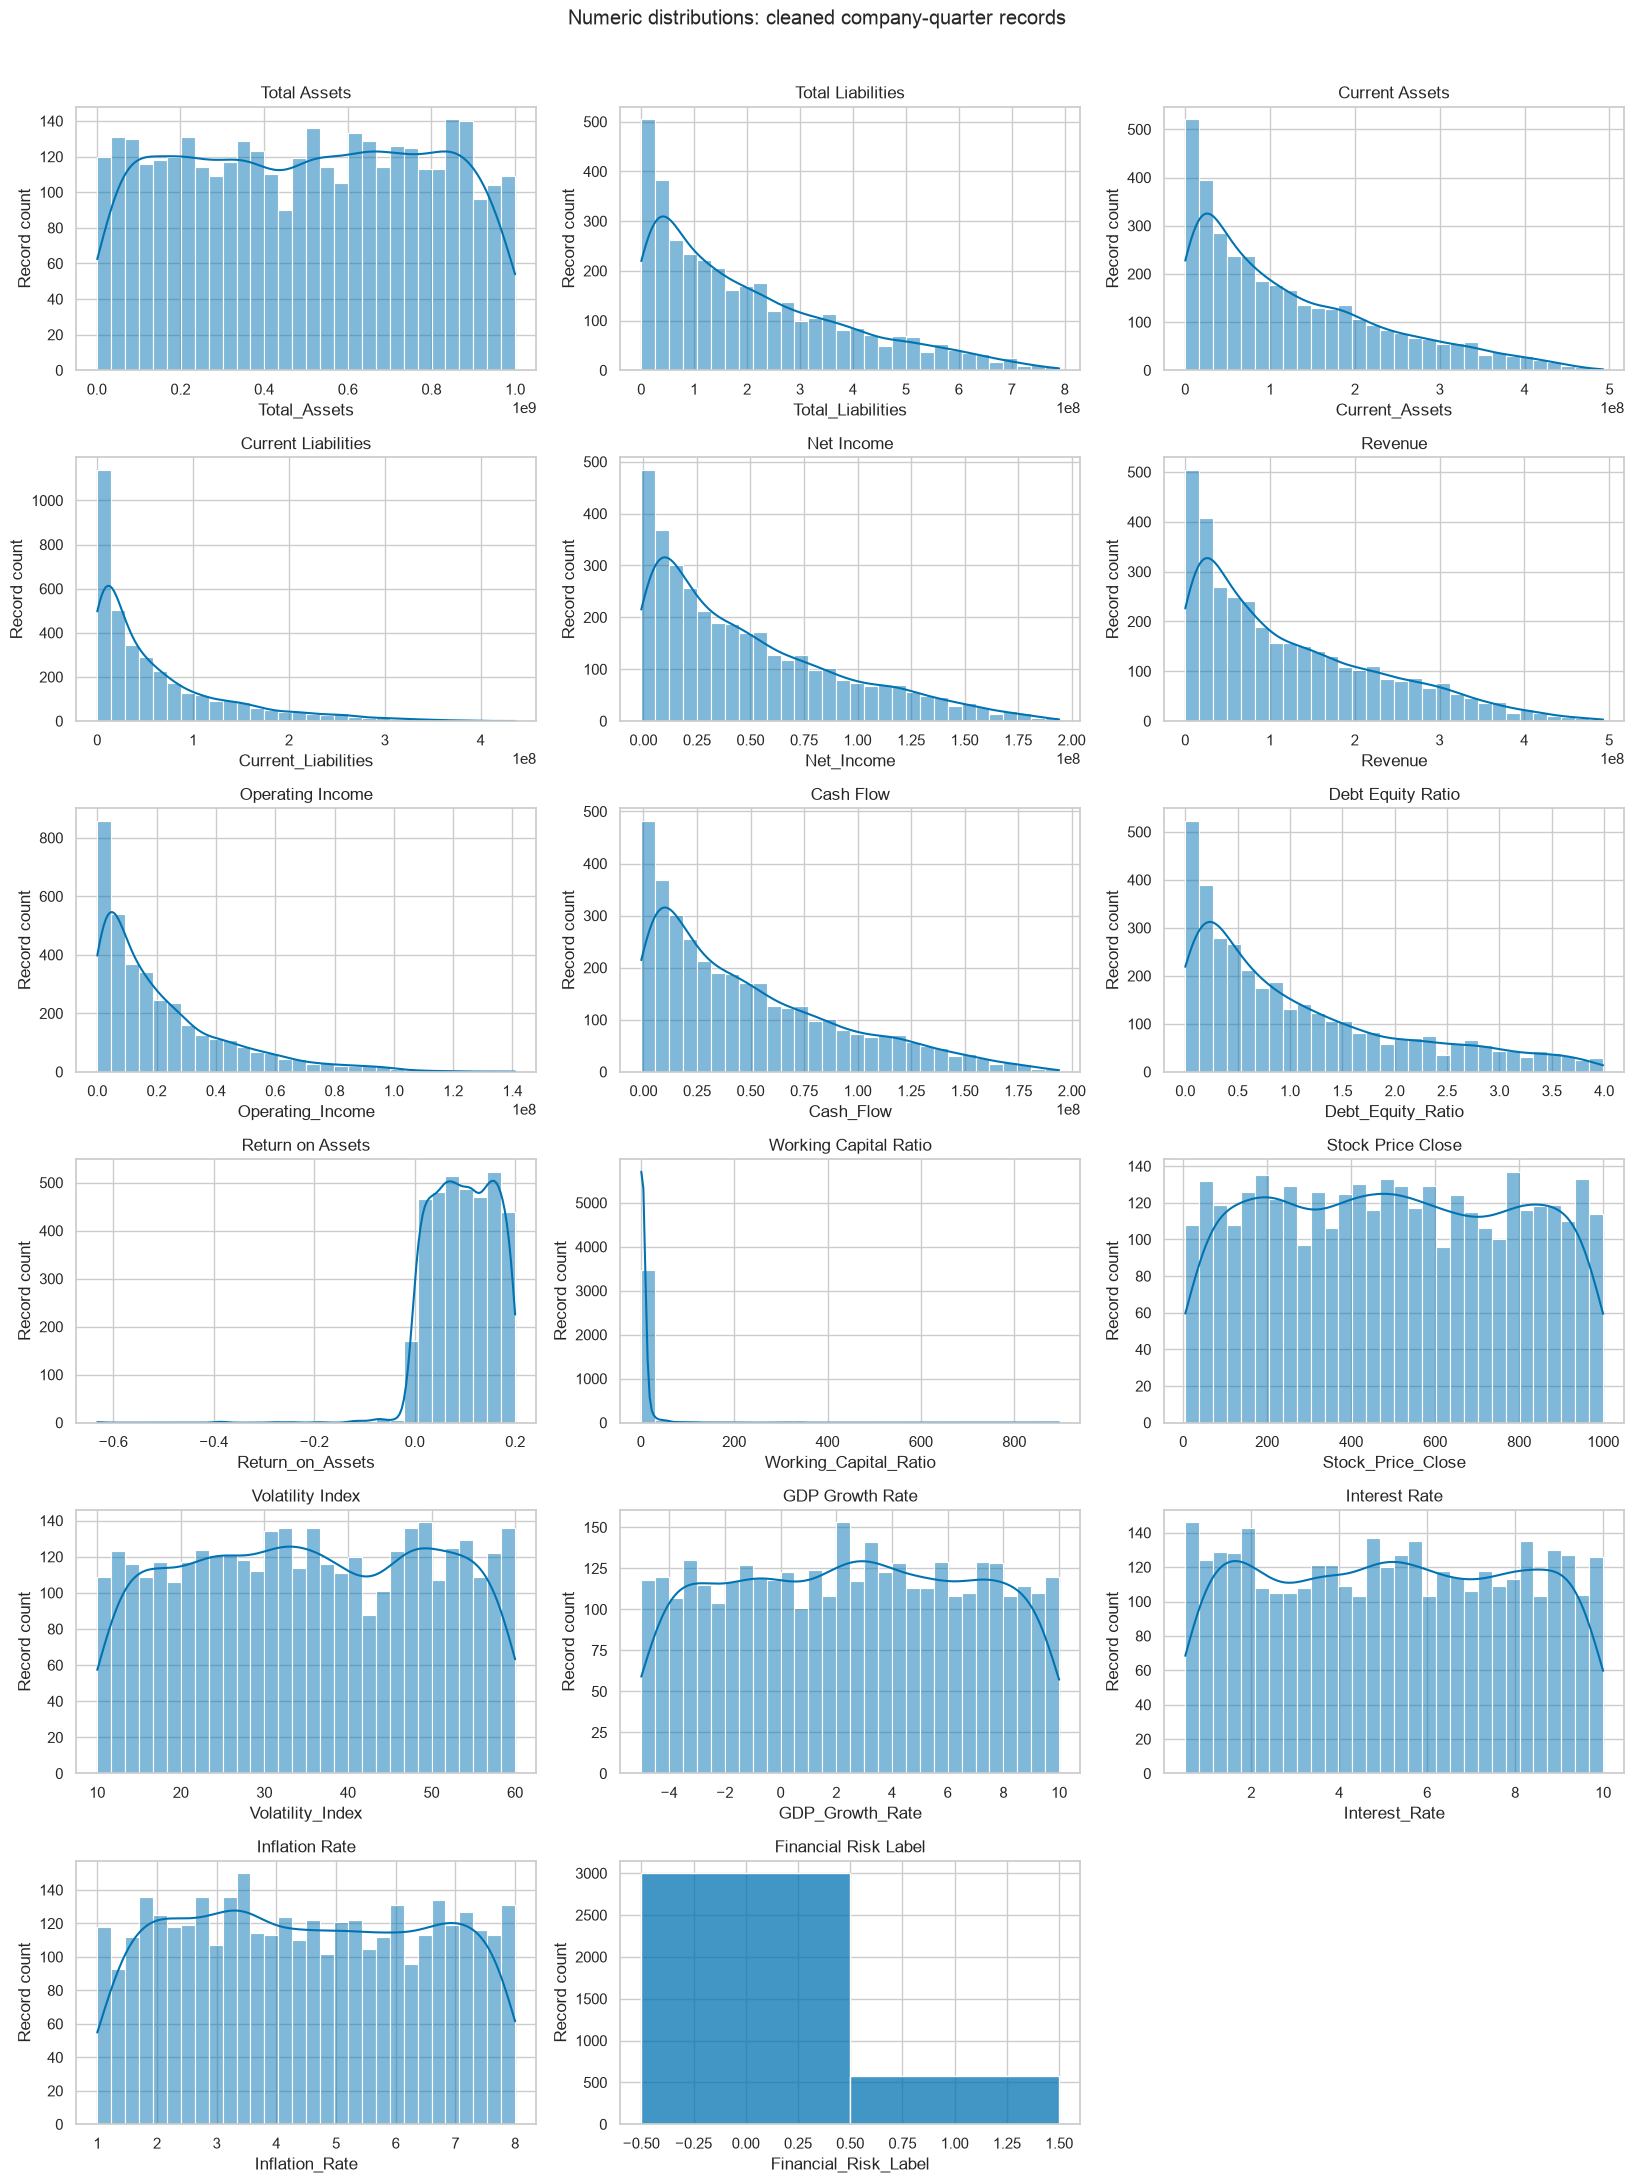

In [5]:
def grid(columns, width=3):
    rows = math.ceil(len(columns) / width)
    fig, axes = plt.subplots(rows, width, figsize=(width * 5.5, rows * 3.6), squeeze=False)
    for ax in axes.flat[len(columns):]:
        ax.set_visible(False)
    return fig, list(axes.flat)

def save_figure(name):
    plt.savefig(figure_dir / f"numerical_{name}.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()

fig, axes = grid(numeric_cols)
for col, ax in zip(numeric_cols, axes):
    sns.histplot(df[col], bins=30 if col != target else [-0.5, 0.5, 1.5],
                 kde=col != target, color=colors[0], ax=ax)
    ax.set(title=col.replace("_", " "), xlabel=col, ylabel="Record count")
fig.suptitle("Numeric distributions: cleaned company-quarter records", y=1.01)
fig.tight_layout()
save_figure("distributions")

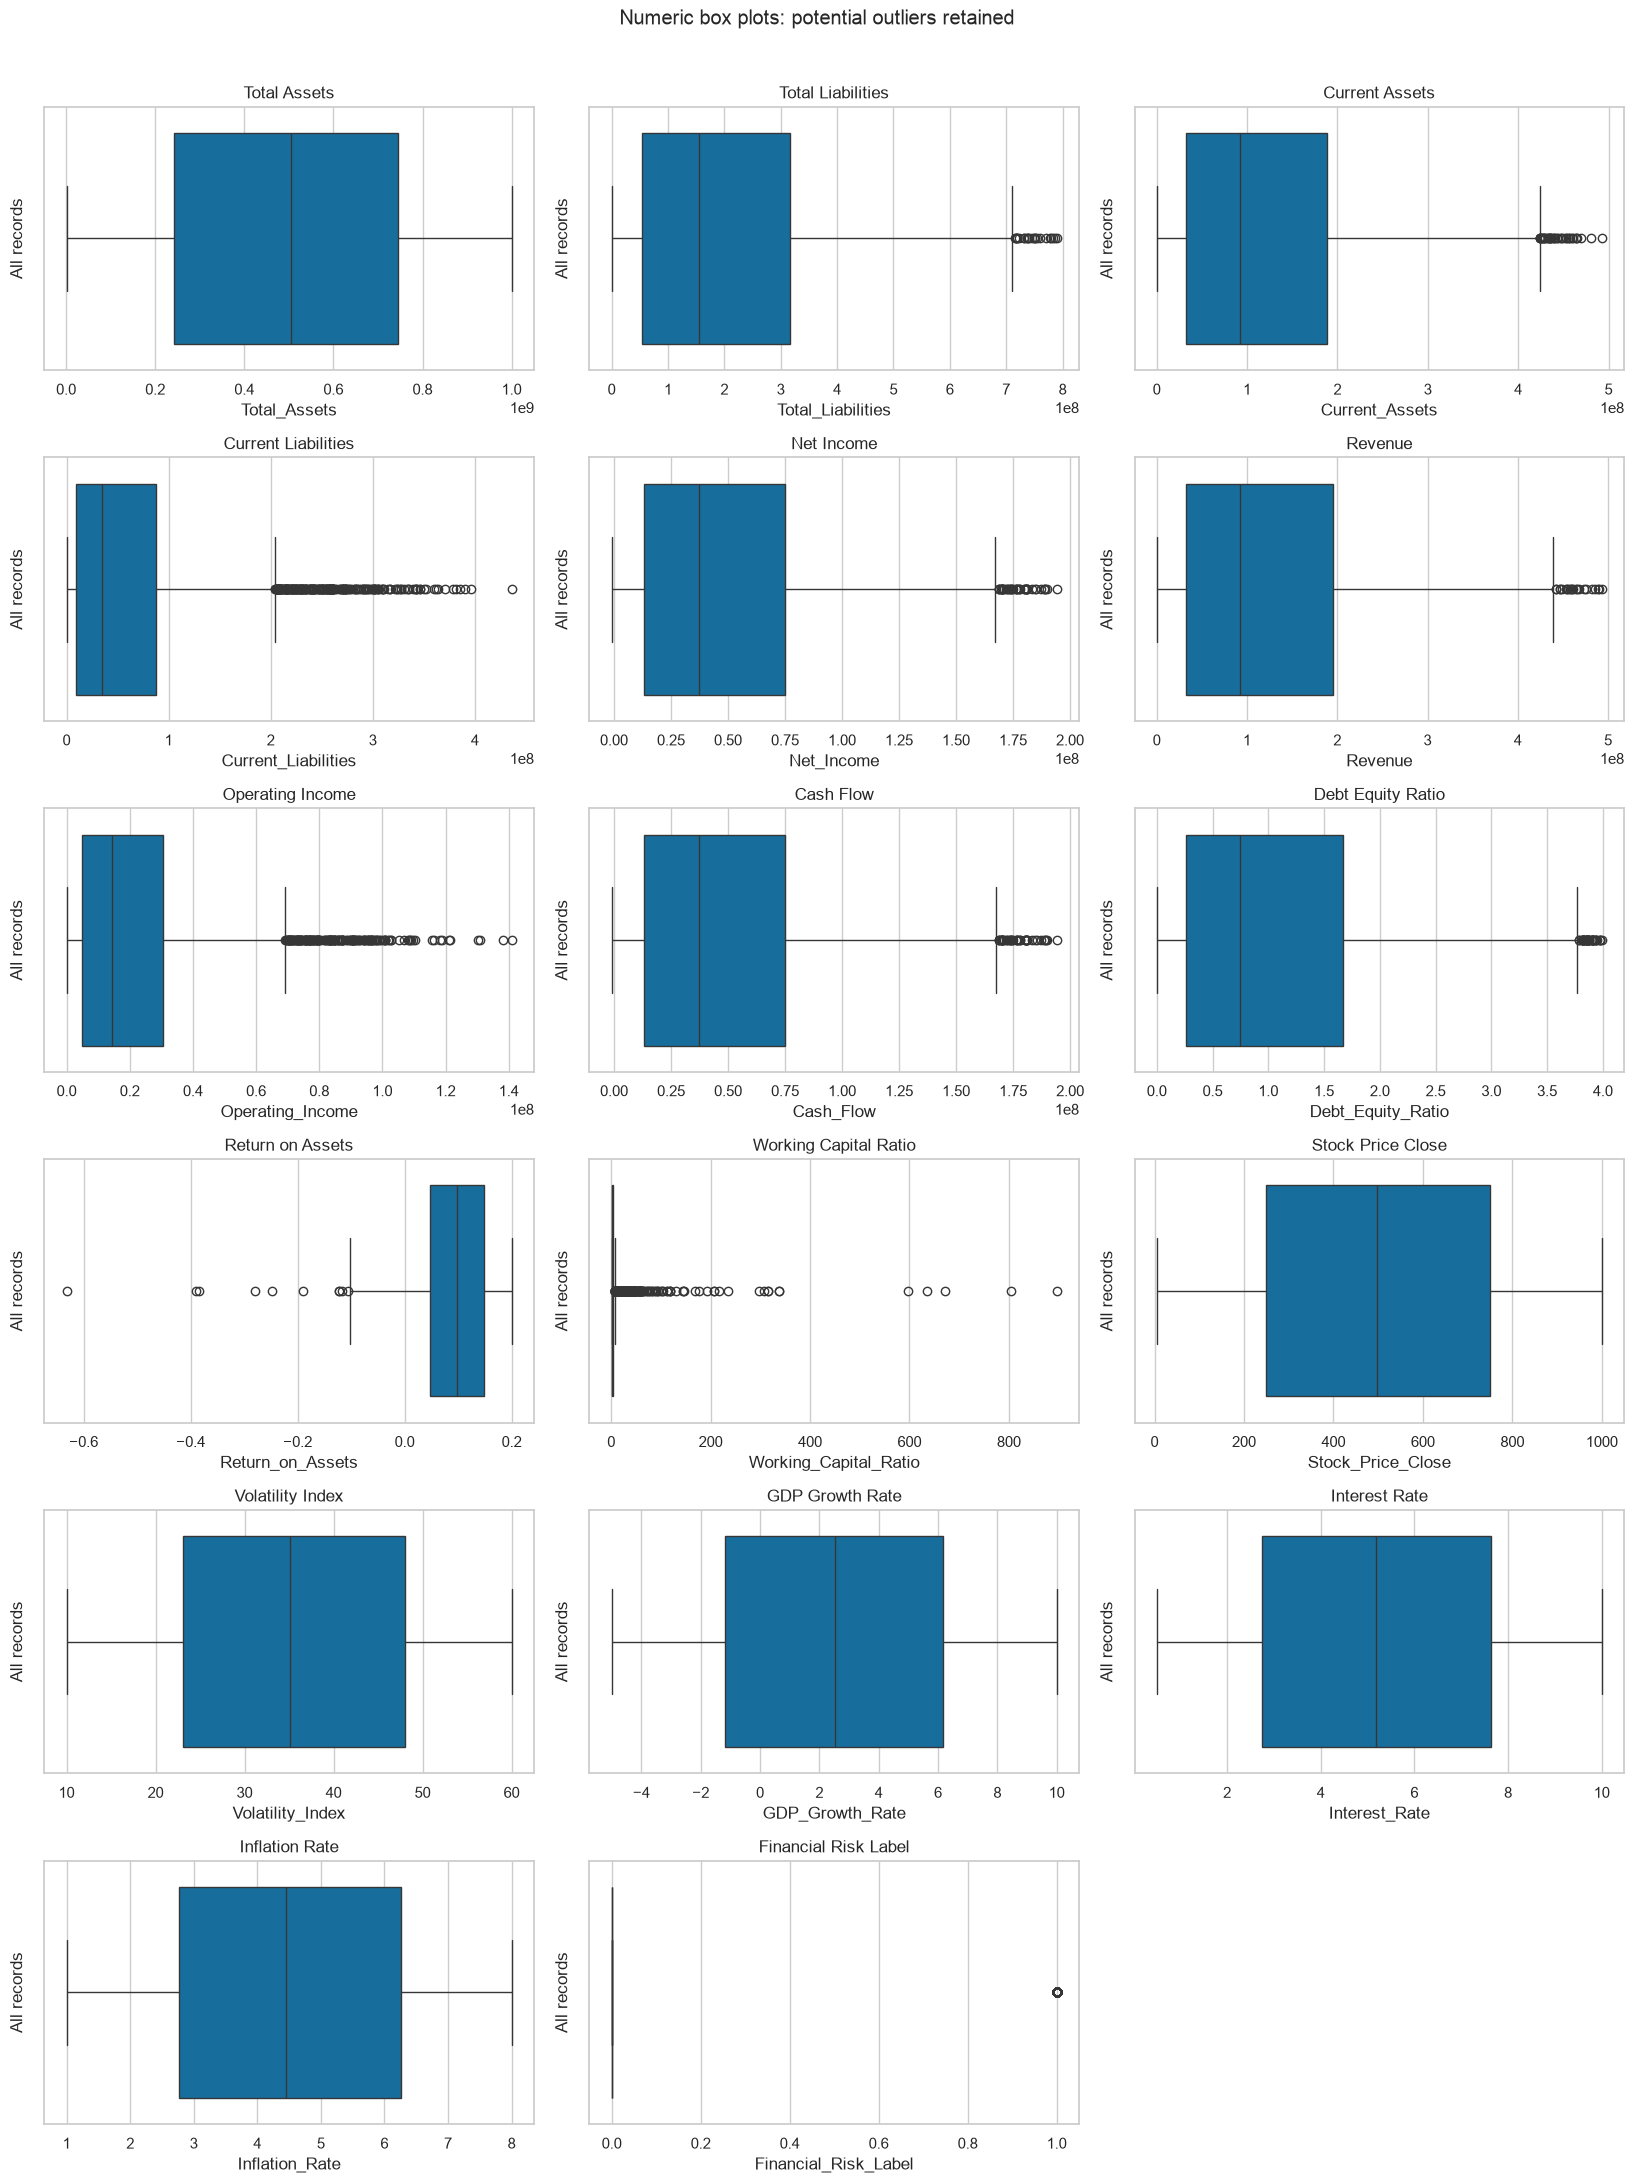

,Skew (absolute value > 1)
Working_Capital_Ratio,17.243263
Current_Liabilities,1.701554
Operating_Income,1.589219
Debt_Equity_Ratio,1.020732


In [6]:
fig, axes = grid(numeric_cols)
for col, ax in zip(numeric_cols, axes):
    sns.boxplot(x=df[col], color=colors[0], ax=ax)
    ax.set(title=col.replace("_", " "), xlabel=col, ylabel="All records")
fig.suptitle("Numeric box plots: potential outliers retained", y=1.01)
fig.tight_layout()
save_figure("boxplots")
heavy_skew = stats.loc[feature_cols, "skew"].loc[lambda x: x.abs() > 1].sort_values(ascending=False)
display(heavy_skew.to_frame("Skew (absolute value > 1)"))

## 5. Correlations
Pearson correlation measures linear association from −1 to +1. All numeric columns are shown, including the binary label. Label correlations describe association with 0/1 membership, not causation or predictive performance. Company_ID and Date are not financial measurements and are excluded. Check the company count before treating this dataset as a longitudinal company panel.

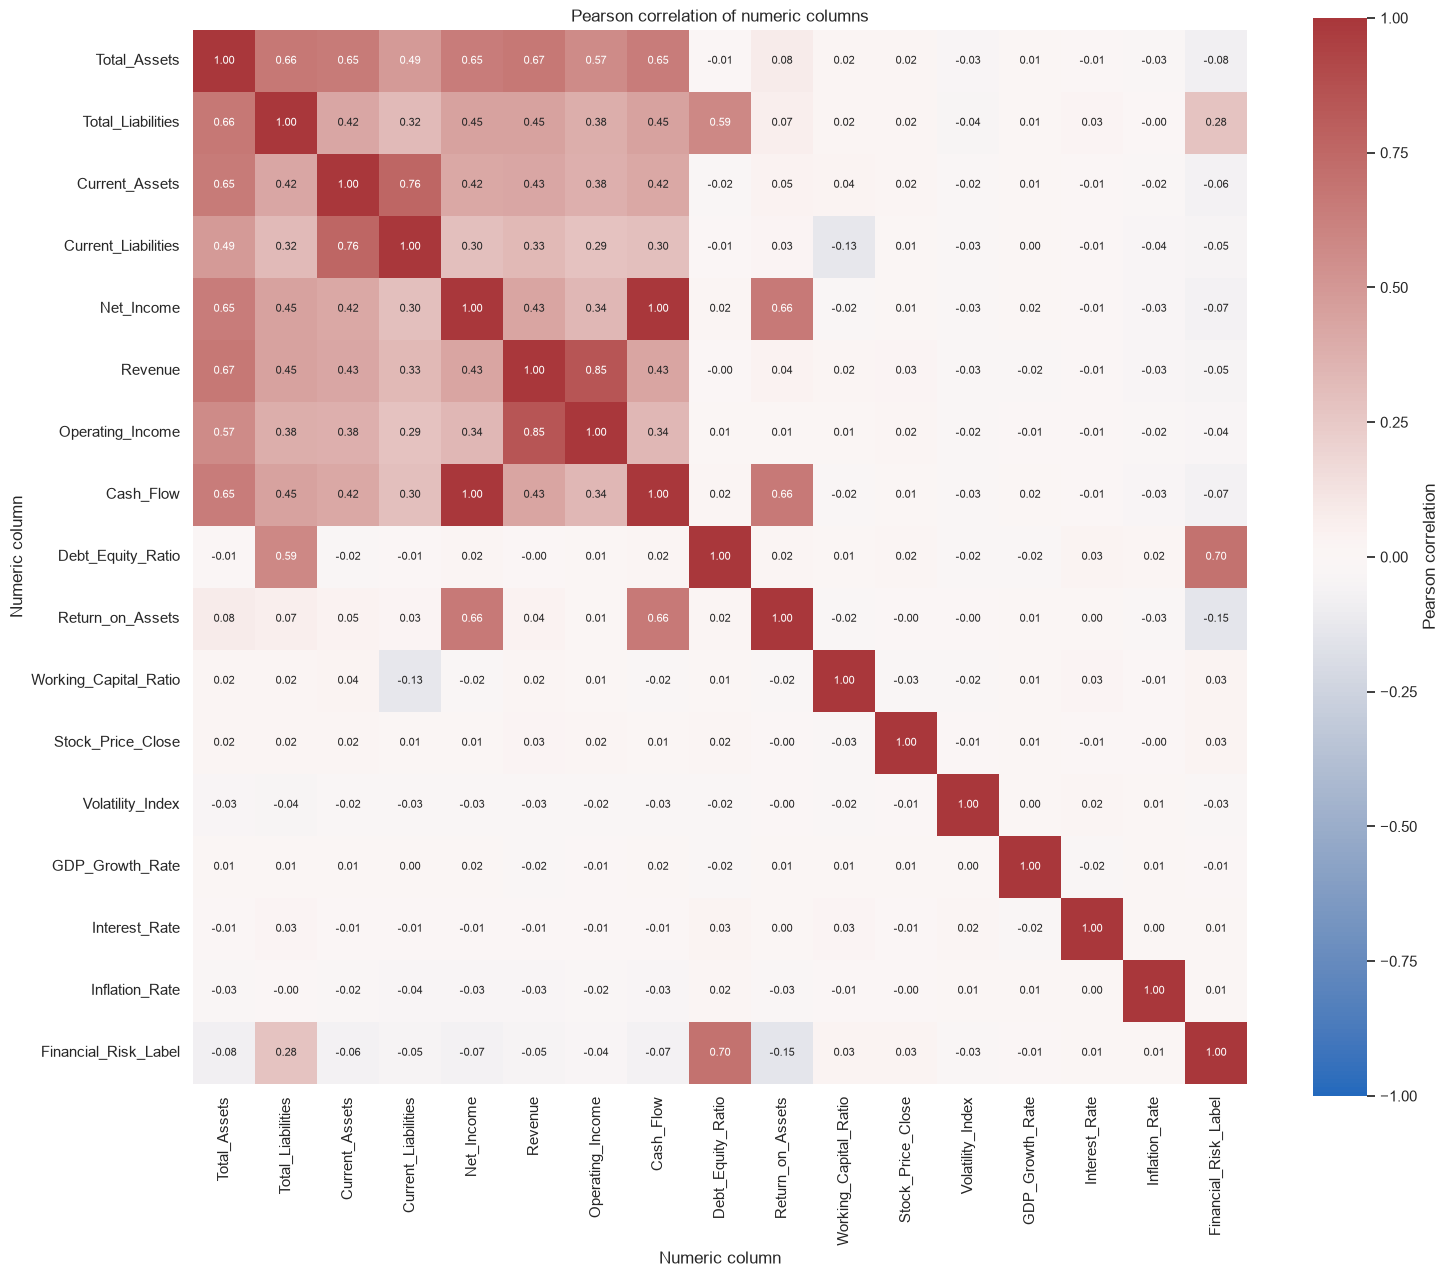

,Column 1,Column 2,correlation,absolute correlation
75,Net_Income,Cash_Flow,0.999999,0.999999
91,Revenue,Operating_Income,0.848604,0.848604
37,Current_Assets,Current_Liabilities,0.761026,0.761026
152,Debt_Equity_Ratio,Financial_Risk_Label,0.701984,0.701984
5,Total_Assets,Revenue,0.667805,0.667805
1,Total_Assets,Total_Liabilities,0.664530,0.664530
128,Cash_Flow,Return_on_Assets,0.662236,0.662236
77,Net_Income,Return_on_Assets,0.662203,0.662203
2,Total_Assets,Current_Assets,0.650597,0.650597
4,Total_Assets,Net_Income,0.647905,0.647905


,Correlation with risk label
Debt_Equity_Ratio,0.701984
Total_Liabilities,0.275970
Return_on_Assets,-0.147855
Total_Assets,-0.081480
Net_Income,-0.066505
Cash_Flow,-0.066493
Current_Assets,-0.062985
Revenue,-0.052135
Current_Liabilities,-0.048791
Operating_Income,-0.035084


In [7]:
corr = df[numeric_cols].corr()
plt.figure(figsize=(17, 14))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0,
            vmin=-1, vmax=1, square=True, annot_kws={"size": 8},
            cbar_kws={"label": "Pearson correlation"})
plt.title("Pearson correlation of numeric columns")
plt.xlabel("Numeric column")
plt.ylabel("Numeric column")
save_figure("correlation")

upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
pairs = upper.stack().rename("correlation").reset_index()
pairs.columns = ["Column 1", "Column 2", "correlation"]
pairs["absolute correlation"] = pairs["correlation"].abs()
display(pairs.sort_values("absolute correlation", ascending=False).head(10))
risk_corr = corr.loc[feature_cols, target].sort_values(key=lambda x: x.abs(), ascending=False)
display(risk_corr.to_frame("Correlation with risk label"))

## 6. Key financial features by risk label
Compare debt, profitability, working capital, and volatility across labels 0 and 1. Labels are shown using their stored values so their business meaning is not inferred from the data alone. All observations, including extreme values, are retained.

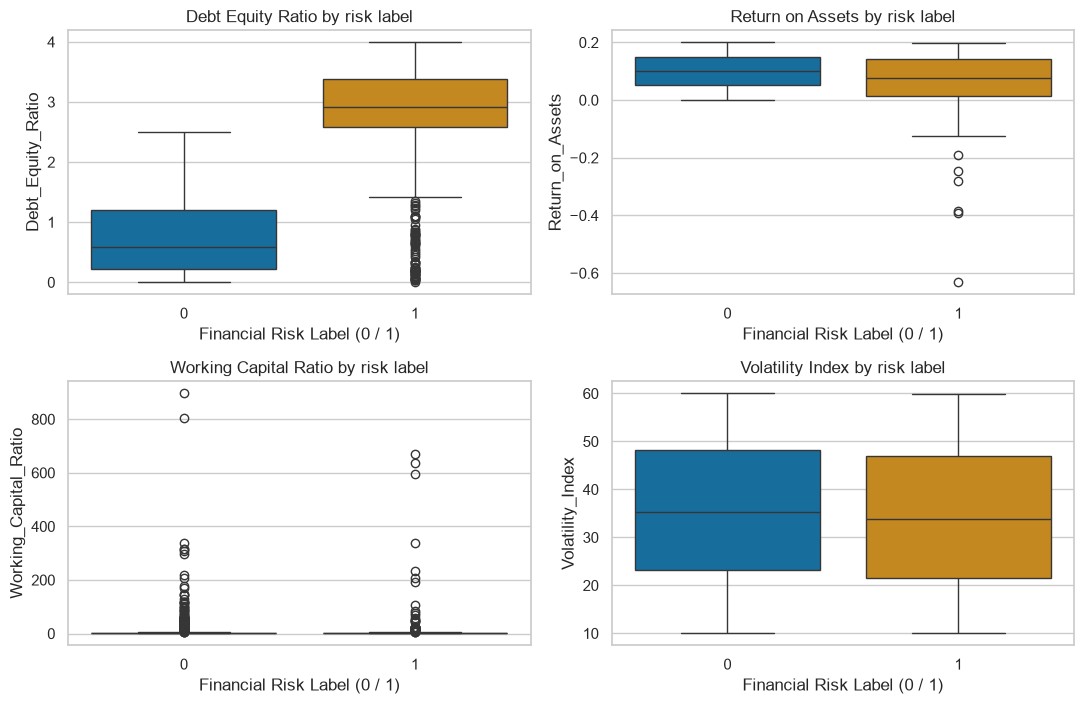

Financial_Risk_Label,Label 0 median,Label 1 median
Debt_Equity_Ratio,0.59,2.920
Return_on_Assets,0.10,0.077
Working_Capital_Ratio,1.95,1.890
Volatility_Index,35.31,33.870


In [8]:
key_features = [col for col in ["Debt_Equity_Ratio", "Return_on_Assets",
                                "Working_Capital_Ratio", "Volatility_Index"] if col in feature_cols]
assert key_features, "No requested financial features found"
fig, axes = grid(key_features, width=2)
for col, ax in zip(key_features, axes):
    sns.boxplot(data=df, x=target, y=col, hue=target, order=[0, 1],
                palette={0: colors[0], 1: colors[1]}, dodge=False, ax=ax)
    if ax.get_legend() is not None:
        ax.get_legend().remove()
    ax.set(title=f"{col.replace('_', ' ')} by risk label",
           xlabel="Financial Risk Label (0 / 1)", ylabel=col)
fig.tight_layout()
save_figure("risk_comparison")
display(df.groupby(target)[key_features].median().T.rename(columns={0: "Label 0 median", 1: "Label 1 median"}))

## 7. IQR outlier audit
An observation is flagged when it is below Q1 − 1.5×IQR or above Q3 + 1.5×IQR. These flags identify unusual values, not confirmed errors. Counts are per column and may overlap. The binary label is reported separately because IQR is not a meaningful outlier rule for class membership.

,Q1,Q3,IQR,Lower bound,Upper bound,Flagged count,Flagged percent,Interpretation
Financial_Risk_Label,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,575,16.0839,Binary class: IQR flags are not meaningful out...
Working_Capital_Ratio,1.310000e+00,3.820000e+00,2.510000e+00,-2.455000e+00,7.585000e+00,436,12.1958,Potential numeric outliers; retained
Current_Liabilities,9.699961e+06,8.747053e+07,7.777057e+07,-1.069559e+08,2.041264e+08,225,6.2937,Potential numeric outliers; retained
Operating_Income,4.931102e+06,3.062379e+07,2.569269e+07,-3.360793e+07,6.916282e+07,177,4.9510,Potential numeric outliers; retained
Net_Income,1.300611e+07,7.518644e+07,6.218033e+07,-8.026439e+07,1.684569e+08,44,1.2308,Potential numeric outliers; retained
Cash_Flow,1.304357e+07,7.513599e+07,6.209242e+07,-8.009505e+07,1.682746e+08,44,1.2308,Potential numeric outliers; retained
Debt_Equity_Ratio,2.600000e-01,1.670000e+00,1.410000e+00,-1.855000e+00,3.785000e+00,42,1.1748,Potential numeric outliers; retained
Current_Assets,3.212730e+07,1.888287e+08,1.567014e+08,-2.029248e+08,4.238808e+08,40,1.1189,Potential numeric outliers; retained
Total_Liabilities,5.310908e+07,3.165896e+08,2.634805e+08,-3.421117e+08,7.118103e+08,24,0.6713,Potential numeric outliers; retained
Revenue,3.225623e+07,1.951986e+08,1.629424e+08,-2.121574e+08,4.396123e+08,22,0.6154,Potential numeric outliers; retained


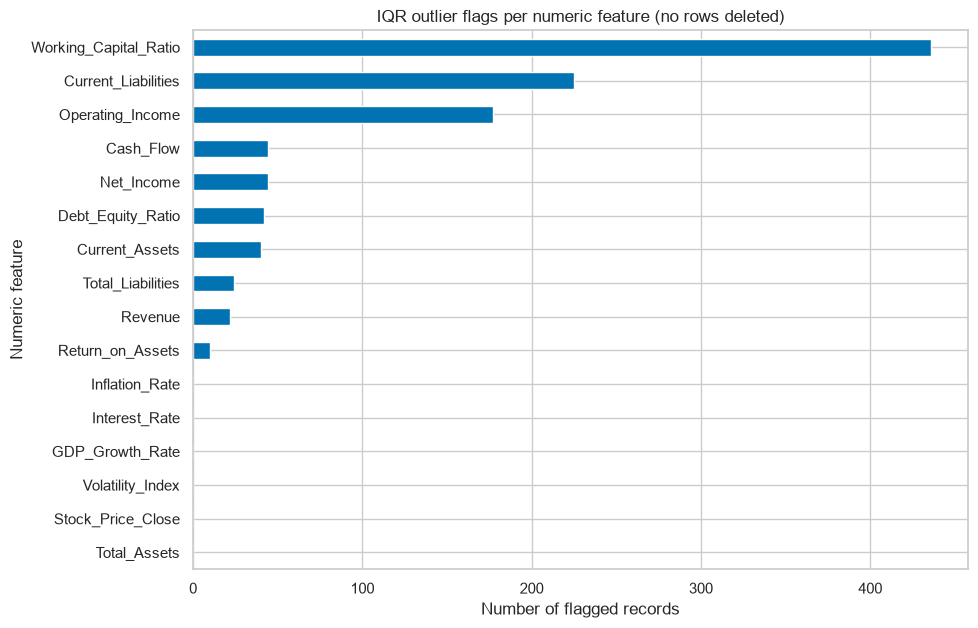

In [9]:
q1 = df[numeric_cols].quantile(0.25)
q3 = df[numeric_cols].quantile(0.75)
iqr = q3 - q1
lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
flags = df[numeric_cols].lt(lower) | df[numeric_cols].gt(upper)
outliers = pd.DataFrame({"Q1": q1, "Q3": q3, "IQR": iqr,
                         "Lower bound": lower, "Upper bound": upper,
                         "Flagged count": flags.sum(), "Flagged percent": flags.mean() * 100})
outliers["Interpretation"] = "Potential numeric outliers; retained"
outliers.loc[target, "Interpretation"] = "Binary class: IQR flags are not meaningful outliers"
display(outliers.sort_values("Flagged count", ascending=False).round(4))
plt.figure(figsize=(10, 7))
counts = outliers.loc[feature_cols, "Flagged count"].sort_values()
counts.plot.barh(color=colors[0])
plt.title("IQR outlier flags per numeric feature (no rows deleted)")
plt.xlabel("Number of flagged records")
plt.ylabel("Numeric feature")
save_figure("outliers")

## 8. Key findings
The following plain-English findings are computed from the displayed analysis. They summarize this cleaned dataset and do not establish cause and effect.

In [10]:
strongest = pairs.sort_values("absolute correlation", ascending=False).iloc[0]
most_skewed = stats.loc[feature_cols, "skew"].abs().idxmax()
most_outliers = outliers.loc[feature_cols, "Flagged count"].idxmax()
top_risk = risk_corr.index[0]
medians = df.groupby(target)[key_features].median()
comparison = "; ".join(f"{col}: {medians.loc[0, col]:.3f} versus {medians.loc[1, col]:.3f}" for col in key_features[:2])
findings = [
    f"The analysis uses {len(df):,} records and {df.shape[1]} columns. {len(raw)-len(df):,} exact duplicate rows were removed from the raw file; no conflicting company-date records remain after exact deduplication.",
    f"No missing values remain in the cleaned file. It includes {df['Company_ID'].nunique():,} distinct Company_ID values. Compare this count with the row count before interpreting records as repeated company observations.",
    f"Label 1 represents {(df[target] == 1).mean():.1%} of records ({(df[target] == 1).sum():,}); label 0 represents the remaining records. The groups are unequal in size.",
    f"{most_skewed} has the most asymmetric feature distribution (skew {stats.loc[most_skewed, 'skew']:.2f}). A few extreme values make the mean less representative than the median.",
    f"The strongest numeric pair is {strongest['Column 1']} and {strongest['Column 2']} (correlation {strongest['correlation']:.2f}). This indicates association, not proof that one causes the other.",
    f"{top_risk} has the strongest absolute linear association with the risk label (correlation {risk_corr.iloc[0]:.2f}). This alone does not show how well a future model would perform.",
    f"Group medians (label 0 versus label 1) include {comparison}. The comparison describes the observed groups only.",
    f"{most_outliers} has the most IQR flags among features: {int(outliers.loc[most_outliers, 'Flagged count']):,} ({outliers.loc[most_outliers, 'Flagged percent']:.1f}%). All flagged values were retained; they need context before being treated as errors."
]
display(Markdown("\n".join("- " + finding for finding in findings)))

- The analysis uses 3,575 records and 20 columns. 1,425 exact duplicate rows were removed from the raw file; no conflicting company-date records remain after exact deduplication.
- No missing values remain in the cleaned file. It includes 3,575 distinct Company_ID values. Compare this count with the row count before interpreting records as repeated company observations.
- Label 1 represents 16.1% of records (575); label 0 represents the remaining records. The groups are unequal in size.
- Working_Capital_Ratio has the most asymmetric feature distribution (skew 17.24). A few extreme values make the mean less representative than the median.
- The strongest numeric pair is Net_Income and Cash_Flow (correlation 1.00). This indicates association, not proof that one causes the other.
- Debt_Equity_Ratio has the strongest absolute linear association with the risk label (correlation 0.70). This alone does not show how well a future model would perform.
- Group medians (label 0 versus label 1) include Debt_Equity_Ratio: 0.590 versus 2.920; Return_on_Assets: 0.100 versus 0.077. The comparison describes the observed groups only.
- Working_Capital_Ratio has the most IQR flags among features: 436 (12.2%). All flagged values were retained; they need context before being treated as errors.

## Reproducibility and scope
Use **Kernel → Restart Kernel and Run All Cells**, then save the notebook. The raw and cleaned data stay local and must not be committed. Commit only this notebook and `reports/figures/numerical_*.png`. No source code, environment configuration, or README changes are needed. No models, outlier removal, or additional cleaning are performed here.